# XPLT Explorer — Multi-Case FEBio Post-Processor

Loads one or more `.feb` / `.xplt` simulation cases and computes:
- Facet geometry (centroids, areas)
- Contact pressure time-series per facet
- Contact Surface Area Ratio (CSAR) vs time
- Multi-case CSAR comparison

All heavy parsing and computation lives in **`xplt_core.py`**.  
You only need to edit the **Configuration** cell below.

In [35]:
import xplt_core as xc
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Configuration

Edit this cell to define your simulation cases and analysis parameters.
- Add one `dict` entry per case.  `label` is used in plot titles and file names.
- The sliding contact surface is **detected automatically** from the `.feb` Contact
  definitions — no need to specify material names or surface names.
  Per-material Z bounds are derived from domain geometry automatically.
- `ZMIN` / `ZMAX` set the Z-window for single-region CSAR analysis (millimetres).
  Leave as `None` to use the full catheter Z range derived automatically.

In [36]:
# ── Simulation cases ──────────────────────────────────────────────────────────
# Add as many cases as you like; compare them in the CSAR section below.
#
# contact_surface_name : optional — leave out to auto-detect the sliding-elastic
#   primary surface from the .feb Contact definitions.
#   Only needed if auto-detection picks the wrong surface.
CASE_DEFS = [
    dict(
        feb_path       = 'sample.feb',
        xplt_path      = 'sample.xplt',
        label          = 'sample',
        tip_z_cutoff   = 50.0,   # fallback Z cutoff [mm] if no material domains found
        cp_var_id      = 1,      # xplt variable ID for contact pressure
    ),
    # dict(
    #     feb_path       = 'sample2.feb',
    #     xplt_path      = 'sample2.xplt',
    #     label          = 'sample2',
    #     tip_z_cutoff   = 50.0,
    #     cp_var_id      = 1,
    # ),
]

# ── CSAR analysis window ───────────────────────────────────────────────────────
# Set to None to use the full catheter Z range derived from material domains automatically.
ZMIN = None   # mm  (or e.g. 0.0)
ZMAX = None   # mm  (or e.g. 50.0)

## Load Cases

Run this cell once (or re-run after changing `CASE_DEFS`).
Parsing is automatic — no further setup needed.

In [37]:
cases = [xc.SimulationCase(**d) for d in CASE_DEFS]

[sample] Parsing sample.feb …
[sample] Reading sample.xplt …
[sample] Parsing 180 timesteps …
[sample] Ready  |  23734 facets  |  180 timesteps  |  t = [0.000 … 30.350] s  |  max cp = 0.0169 MPa  |  insertion depth = [0.00 … 270.72] mm


## Simulation Summary

In [38]:
for case in cases:
    print(case.summary())
    print(f'\n  Available xplt surfaces:')
    for sid, name in sorted(case.surface_names.items()):
        print(f'    id={sid:2d}  "{name}"')
    print()

SimulationCase: sample
  FEB  : sample.feb
  XPLT : sample.xplt
  Contact surface  : 'catheter_slidePrimary' (id=3)
  Facets           : 23734
  Total area       : 5752.72 mm²
  Tip Z range      : [-0.40, 402.60] mm
  Timesteps        : 180  (0.000 → 30.350 s)
  Max cp overall   : 0.0169 MPa
  Materials        : "catheter_body", "catheter_tip", "zone1", "zone2", "zone3", "zone4"

  Available xplt surfaces:
    id= 1  "cath_tail_zero_rot"
    id= 2  "cath_tail_xy_zero_disp"
    id= 3  "catheter_slidePrimary"
    id= 4  "catheter_slideSecondary"
    id= 5  "cath_body_tip_tied_contactPrimary"
    id= 6  "cath_body_tip_tied_contactSecondary"
    id= 7  "z1z2TiedPrimary"
    id= 8  "z1z2TiedSecondary"
    id= 9  "z2z3TiedPrimary"
    id=10  "z3z4TiedSecondary"
    id=11  "zero_disp_bladder"
    id=12  "z2z3TiedSecondary"
    id=13  "z3z4TiedPrimary"



## Facet Geometry

2-D projections of facet centroids. Orange = tip zone, blue = body.
The red dashed lines mark the tip Z boundaries derived from the material domain.

Saved: sample_geometry.png


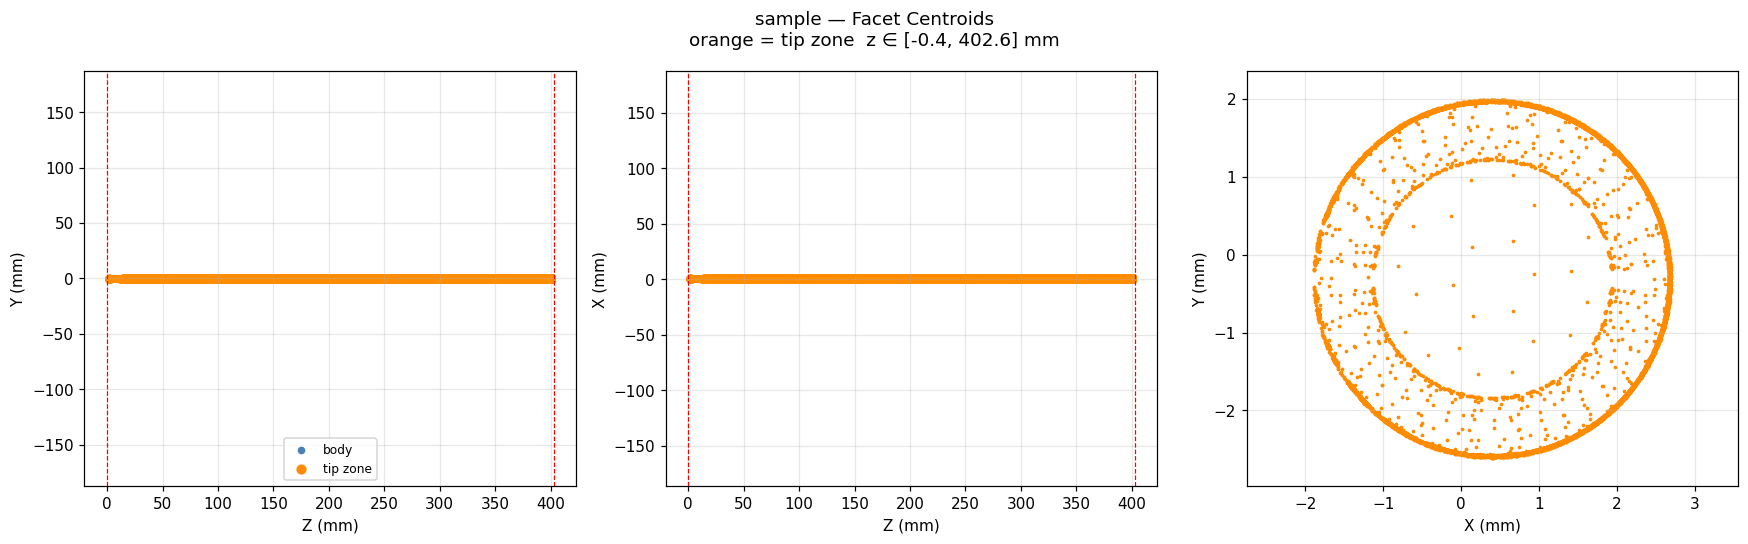

In [39]:
for case in cases:
    xc.plot_geometry(case)

## Contact Pressure Analysis

4-panel overview per case:
1. Max / mean contact pressure vs time
2. Number of facets in contact vs time  
3. Facet map coloured by peak cp
4. Top-10 tip-zone facets individual cp traces

Saved: sample_contact_overview.png


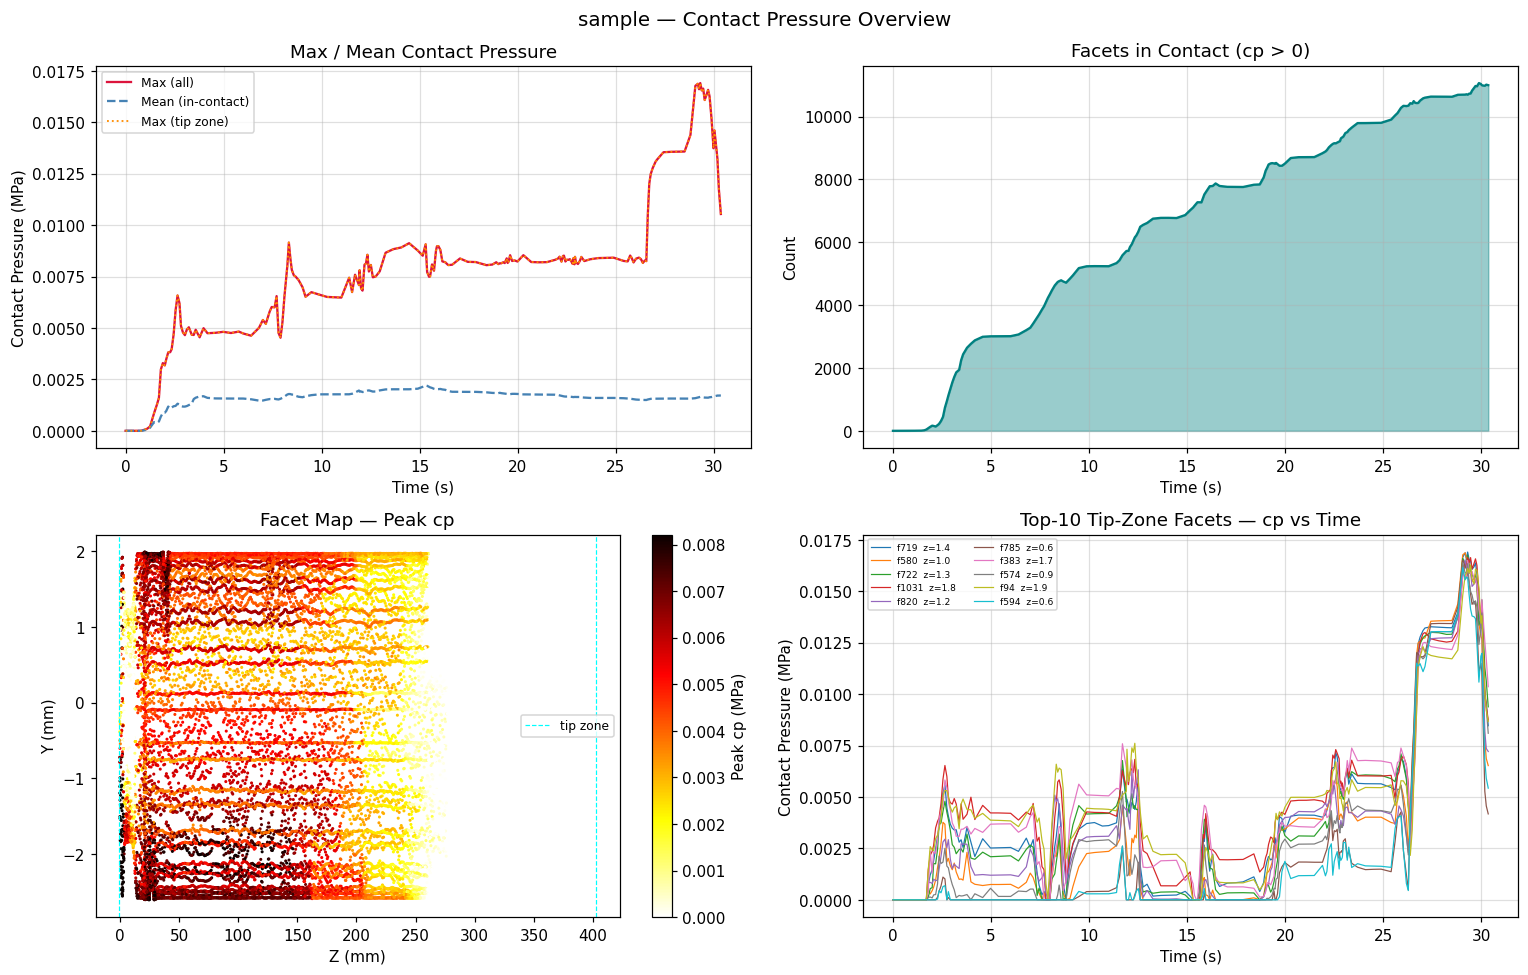

In [40]:
for case in cases:
    xc.plot_contact_overview(case)

## Contact Surface Area Ratio (CSAR)

$$\text{CSAR}(t) = \frac{\displaystyle\sum_{i \in \text{region},\; cp_i(t) > 0} A_i}{\displaystyle\sum_{i \in \text{region}} A_i}$$

`ZMIN` / `ZMAX` were set in the Configuration cell.  
If both are `None`, the tip Z range from the material domain is used automatically.

Saved: sample_csar.png


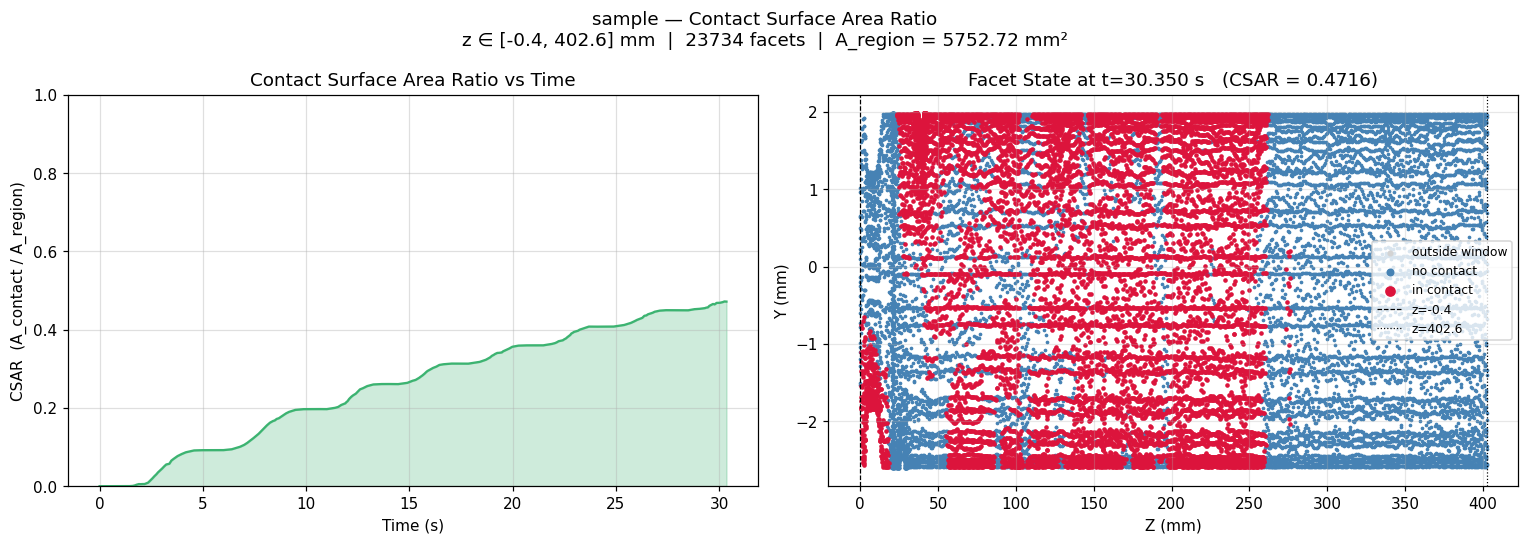

In [41]:
# CSAR plot for each individual case
for case in cases:
    xc.plot_csar(case, zmin=ZMIN, zmax=ZMAX)

Saved: csar_comparison.png
   time_s   sample
 0.000000 0.000000
 0.400000 0.000000
 0.800000 0.000000
 1.100000 0.000131
 1.250000 0.000168
 1.450000 0.000259
 1.600000 0.000736
 1.700000 0.001941
 1.800000 0.003946
 1.900000 0.005383
 2.000000 0.005219
 2.075000 0.005496
 2.175000 0.005509
 2.275000 0.007447
 2.350000 0.009174
 2.450000 0.014280
 2.550000 0.019643
 2.650000 0.025381
 2.750000 0.030545
 2.825000 0.035183
 2.925000 0.040164
 3.025000 0.045089
 3.125000 0.050582
 3.225000 0.055492
 3.375000 0.057274
 3.475000 0.065413
 3.575000 0.069526
 3.775000 0.076988
 3.975000 0.082211
 4.175000 0.086635
 4.575000 0.091387
 4.975000 0.092026
 5.375000 0.092059
 5.775000 0.092098
 6.000000 0.092188
 6.400000 0.094397
 6.800000 0.100743
 7.000000 0.105615
 7.150000 0.110745
 7.350000 0.118956
 7.450000 0.122878
 7.600000 0.129696
 7.700000 0.133932
 7.800000 0.139291
 7.900000 0.144712
 8.000000 0.150034
 8.100000 0.155480
 8.250000 0.162345
 8.325000 0.164541
 8.400000 0.166637
 8.4

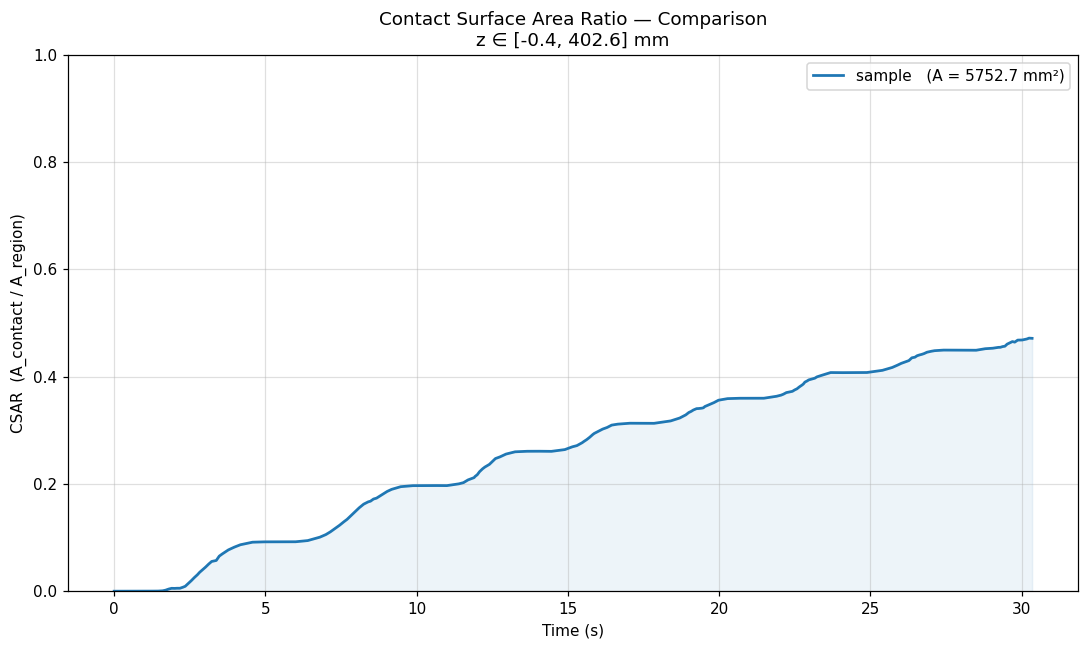

In [42]:
# Multi-case CSAR overlay — meaningful only when more than one case is loaded
xc.compare_csar(cases, zmin=ZMIN, zmax=ZMAX)

# Numeric CSAR table (columns = case labels, rows = timesteps)
df_csar = xc.csar_table(cases, zmin=ZMIN, zmax=ZMAX)
print(df_csar.to_string(index=False))

## Multi-Band CSAR

Split the Z-axis into discrete bands and compute CSAR for each band individually,
plus an **accumulated total** across all bands (union — no double-counting).

- Edit `Z_BANDS_PER_CASE` to define per-case band regions of interest.
- `BAND_LABELS` are optional display names; set to `None` to auto-generate.
- `TOTAL_AREA_OVERRIDE` lets you normalise the accumulated CSAR against a known
  reference area (e.g. from CAD) instead of the sum of facet areas in the bands.


sample — band summary:
  Proximal (0–10 mm)                660 facets  A = 113.39 mm²
  Mid (10–20 mm)                    631 facets  A = 133.52 mm²
  Distal (20–30 mm)                1147 facets  A = 139.79 mm²
  Accumulated (union)              2438 facets  A = 386.69 mm²
Saved: sample_csar_multi_regions.png
Saved: csar_accumulated_comparison.png

Accumulated CSAR table (first 5 rows):
 time_s   sample
   0.00 0.000000
   0.40 0.000000
   0.80 0.000000
   1.10 0.001947
   1.25 0.002501


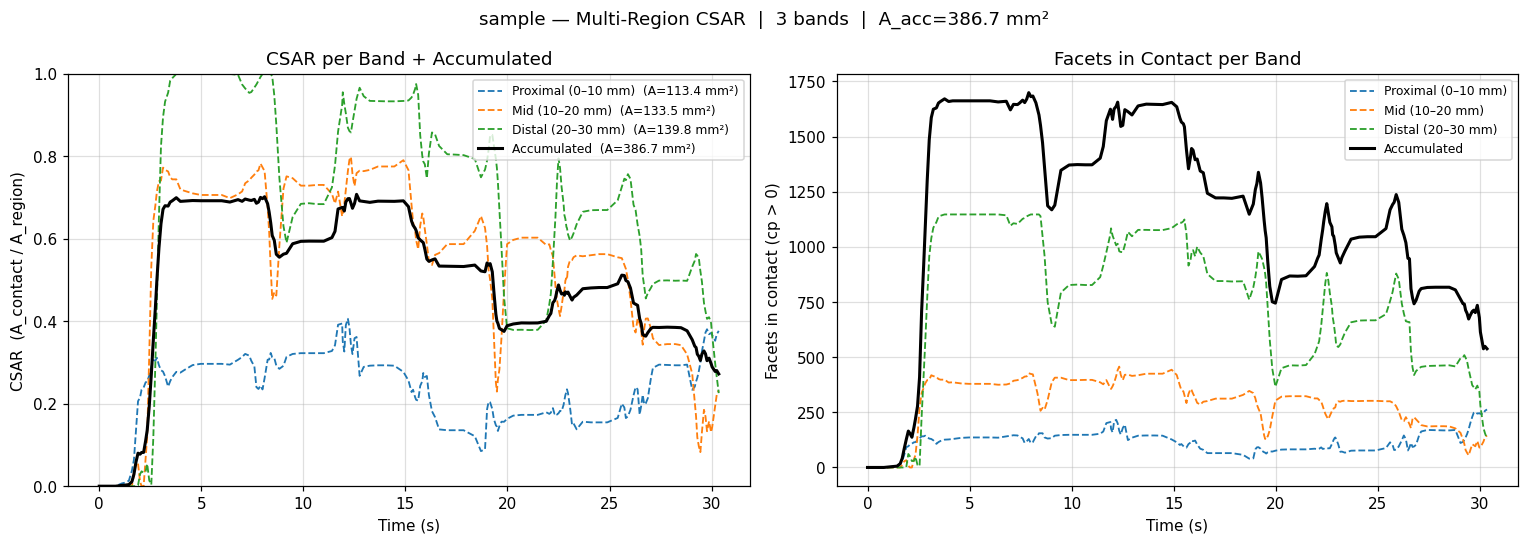

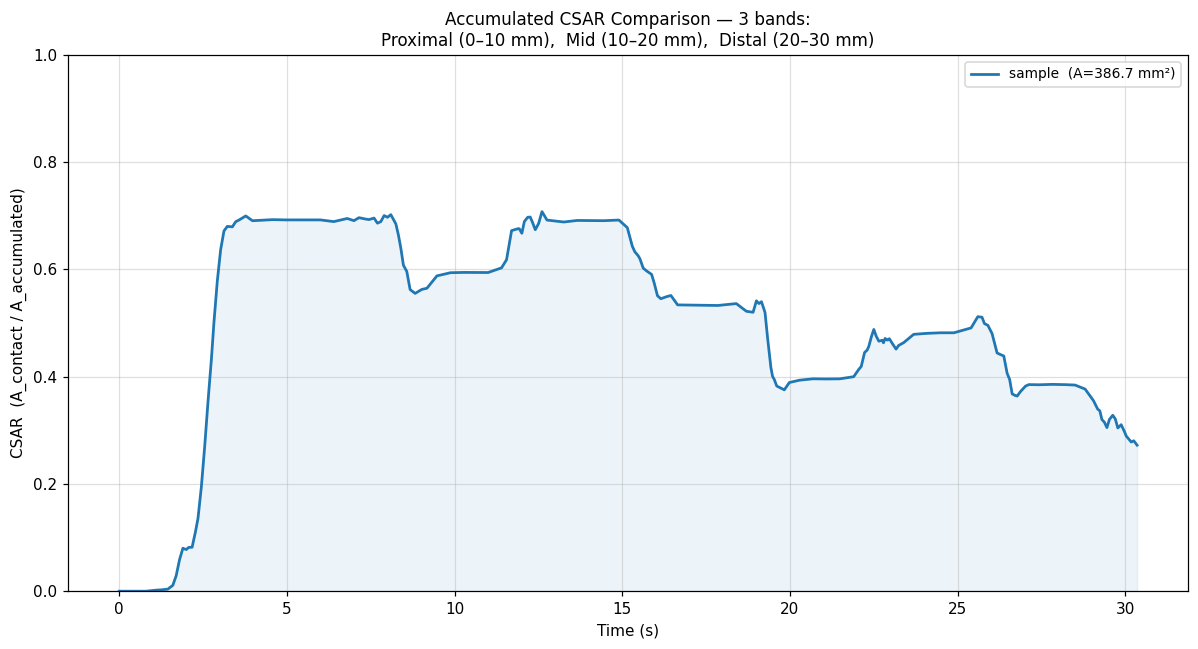

In [43]:
# ── Band definitions (one list of bands per case, same order as CASE_DEFS) ────
# Each inner list contains (zmin, zmax) tuples in mm.  Adjust to match your mesh.
Z_BANDS_PER_CASE = [
    [( 0.0, 10.0),   # proximal
     (10.0, 20.0),   # mid
     (20.0, 30.0)],  # distal  — case 0
    # [(0.0, 35.0)],               # case 1 — uncomment when a second case is loaded
]

# Optional human-readable names for each band (must match bands in each case, or None).
BAND_LABELS = ['Proximal (0–10 mm)', 'Mid (10–20 mm)', 'Distal (20–30 mm)']

# Set to a float [mm²] to normalise the accumulated CSAR against a fixed reference
# area (e.g. from CAD).  None → use the sum of facet areas inside the union of bands.
TOTAL_AREA_OVERRIDE = None

# ── Per-case multi-band plot ───────────────────────────────────────────────
for i, case in enumerate(cases):
    z_bands = Z_BANDS_PER_CASE[i]
    # Raw band statistics — inspect before plotting if needed
    ts, band_stats, accumulated = case.compute_region_accumulation(z_bands)

    print(f'\n{case.label} — band summary:')
    for bs, lbl in zip(band_stats, BAND_LABELS or [f'band {j}' for j in range(len(band_stats))]):
        print(f'  {lbl:30s}  {bs["n_facets_in_region"]:5d} facets  '
              f'A = {bs["total_area_mm2"]:.2f} mm²')
    denom = TOTAL_AREA_OVERRIDE or accumulated['total_area_mm2']
    print(f'  {"Accumulated (union)":30s}  {accumulated["n_facets_in_region"]:5d} facets  '
          f'A = {denom:.2f} mm²')

    xc.plot_csar_multi_regions(case, z_bands, band_labels=BAND_LABELS,
                               total_area_override=TOTAL_AREA_OVERRIDE)

# ── Multi-case accumulated CSAR comparison ──────────────────────────────────────
# Meaningful only when more than one case is loaded.
# Provide one override per case, or None to use computed area.
xc.compare_csar_accumulated(cases, Z_BANDS_PER_CASE,
                             total_area_overrides=[TOTAL_AREA_OVERRIDE] * len(cases))

# ── Numeric table: accumulated CSAR across all bands ──────────────────────
ref_ts = cases[0].timesteps
tbl_data = {'time_s': ref_ts}
for i, case in enumerate(cases):
    z_bands = Z_BANDS_PER_CASE[i]
    ts, _, accumulated = case.compute_region_accumulation(z_bands)
    denom = TOTAL_AREA_OVERRIDE or accumulated['total_area_mm2']
    csar  = np.where(denom > 0, accumulated['contact_area_mm2'] / denom, 0.0)
    if len(ts) != len(ref_ts):
        csar = np.interp(ref_ts, ts, csar)
    tbl_data[case.label] = csar
df_csar_multi = pd.DataFrame(tbl_data)
print('\nAccumulated CSAR table (first 5 rows):')
print(df_csar_multi.head().to_string(index=False))

Saved: max_cp_vs_depth.png


AttributeError: module 'xplt_core' has no attribute 'plot_insertion_depth_vs_time'

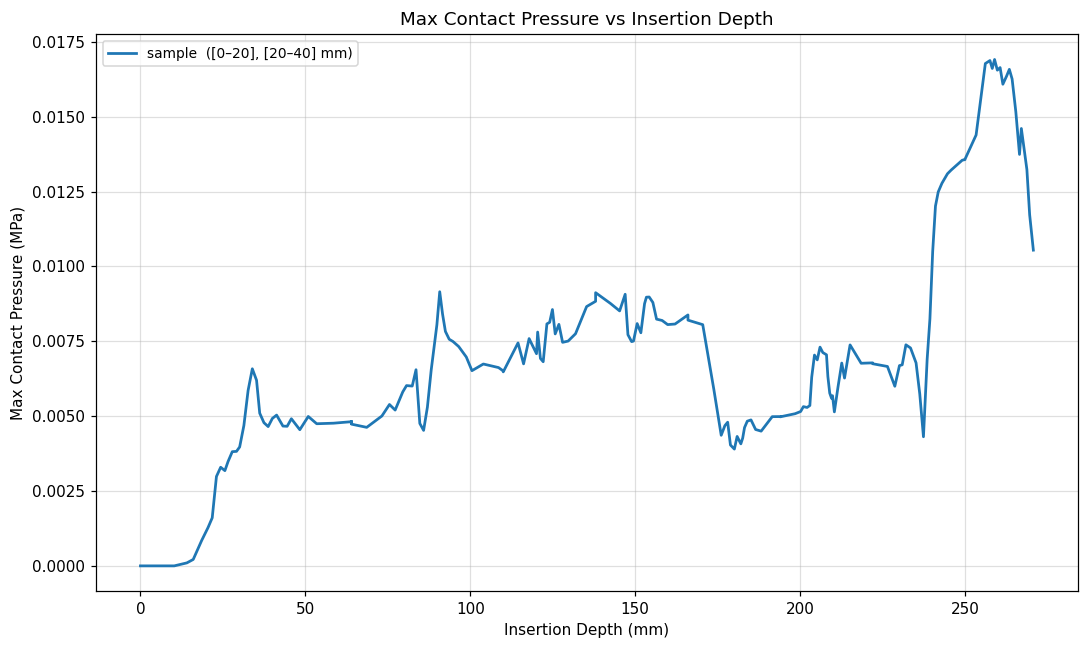

In [ ]:
# ── Per-case Z band definitions for max-cp plot ────────────────────────────────
# One list of (zmin, zmax) tuples per case, in the same order as CASE_DEFS.
# Cases can have different numbers of bands; all bands per case are unioned.
#
# Example with two cases:
#   case 0 (catheter_tip): two bands
#   case 1 (ball-tip):     single band
#
Z_BANDS_PER_CASE = [
    [(0.0, 20.0), (20.0, 40.0)],   # case 0 — adjust zmin/zmax to your mesh
    # [(0.0, 35.0)],               # case 1 — uncomment when a second case is loaded
]

# Optional per-case legend labels (defaults to case.label if None).
CP_DEPTH_LABELS = None   # e.g. ['Design A', 'Design B']

# ── Plot ───────────────────────────────────────────────────────────────────────
xc.plot_max_cp_vs_depth(
    cases,
    z_bands_per_case=Z_BANDS_PER_CASE,
    band_labels=CP_DEPTH_LABELS,
)
xc.plot_insertion_depth_vs_time(cases, save=True)  

## Max Contact Pressure vs Insertion Depth

Plot the maximum contact pressure across a **union of Z bands** vs insertion depth,
with one line per simulation case.

- Each case can have **different Z bands** — define them in `Z_BANDS_PER_CASE`.
- Facets from all bands of a case are unioned before taking the per-timestep max cp.
- X-axis is insertion depth (mm), derived automatically from the `.feb` prescribed z-BCs.

> **Tip:** `material_names` matching is case-insensitive and strips whitespace,
> so `"catheter_tip"`, `"Catheter_Tip"`, and `" catheter_tip "` all work.

## Reaction Force vs Insertion Depth

Plot the net reaction-force magnitude (MPa · mm² = N) summed over all facets in the union of the specified Z bands.

- The reaction force is the vector sum of `traction × facet_area` across the selected facets at each timestep.
- Uses the same `Z_BANDS_PER_CASE` defined above.

In [ ]:
# Reaction force magnitude vs insertion depth
# Reuses Z_BANDS_PER_CASE defined in the Multi-Band CSAR cell above.
# Adjust band_labels as needed.
xc.plot_reaction_force_vs_depth(
    cases,
    z_bands_per_case=Z_BANDS_PER_CASE,
    band_labels=None,   # defaults to case.label
    save=True,
)

## Max Contact Traction vs Insertion Depth

Plot the maximum contact-traction vector magnitude (MPa) over all facets in the union of the specified Z bands, as a function of insertion depth.

- At each timestep the Euclidean norm of the traction vector is computed per facet; the maximum is then taken across all facets in the union.
- Uses the same `Z_BANDS_PER_CASE` defined above.

In [ ]:
# Max contact traction magnitude vs insertion depth
xc.plot_traction_vs_depth(
    cases,
    z_bands_per_case=Z_BANDS_PER_CASE,
    band_labels=None,   # defaults to case.label
    save=True,
)

## CSAR vs Insertion Depth

Plot the accumulated (multi-band union) CSAR against insertion depth instead of simulation time.

- Mirrors the `compare_csar_accumulated` plot but uses insertion depth on the x-axis for easier comparison across cases with different insertion speeds.
- `TOTAL_AREA_OVERRIDE` (from the Multi-Band CSAR cell) is forwarded to each case; set per-case overrides in `total_area_overrides` if they differ.

In [ ]:
# CSAR vs insertion depth — one line per simulation case
xc.plot_csar_vs_depth(
    cases,
    z_bands_per_case=Z_BANDS_PER_CASE,
    total_area_overrides=[TOTAL_AREA_OVERRIDE] * len(cases),
    band_labels=None,   # defaults to case.label
    save=True,
)

## Export

Uncomment whichever exports you need.

In [ ]:
# ── VTP + PVD series (ParaView animation) ─────────────────────────────────────
# Each case exports to its own sub-directory: {label}_vtp/
# for case in cases:
#     case.export_vtp()

# ── Per-facet summary CSV ──────────────────────────────────────────────────────
for case in cases:
    csv_path = f'{case.label}_facet_summary.csv'
    case.df_facets.to_csv(csv_path, index=False)
    print(f'Saved: {csv_path}')

# ── CSAR table CSV ─────────────────────────────────────────────────────────────
df_csar.to_csv('csar_comparison.csv', index=False)
print('Saved: csar_comparison.csv')

Saved: sample_facet_summary.csv
Saved: csar_comparison.csv


In [ ]:
# ── Surrogate-lab compatible CSV export ───────────────────────────────────────
# Exports one row per (facet × timestep) with column names matching surrogate-lab.44
# in the .feb file — no manual depth_scale needed.
#
# To add a new variable later:
#   1. Add a _col_<name>(self) method in SimulationCase (xplt_core.py)
#   2. Register it in SimulationCase.SURROGATE_COLUMNS
#   3. Add the column name to surrogate-lab's configs/config.yaml features.inputs

for case in cases:
    df_sl = case.df_surrogate()
    out_path = f'{case.label}_surrogate.csv'
    df_sl.to_csv(out_path, index=False)
    print(f'Saved: {out_path}  ({len(df_sl):,} rows)')
    print(f'  Columns : {list(df_sl.columns)}')
    print(f'  Depth range: {df_sl["insertion_depth"].min():.2f} … {df_sl["insertion_depth"].max():.2f} mm')


Saved: sample_surrogate.csv  (4,272,120 rows)
  Columns : ['centroid_x', 'centroid_y', 'centroid_z', 'facet_area', 'insertion_depth', 'contact_pressure']
  Depth range: 0.00 … 270.72 mm
